importación de datos

Dataset cargado

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   objid     1000 non-null   int64  
 1   u         1000 non-null   float64
 2   g         1000 non-null   float64
 3   r         1000 non-null   float64
 4   i         1000 non-null   float64
 5   z         1000 non-null   float64
 6   redshift  1000 non-null   float64
 7   class     1000 non-null   str    
dtypes: float64(6), int64(1), str(1)
memory usage: 62.6 KB
None
Revisar datos
                 objid         u         g         r         i         z  \
0  1237645879551000764  25.92735  20.99570  19.24612  18.56461  18.43049   
1  1237645879551066262  19.38905  18.24496  17.58728  17.20807  16.90905   
2  1237645879562862699  20.14134  19.28787  19.04397  18.96897  18.79573   
3  1237645879562928144  21.50923  19.69340  18.47973  17.91998  17.55132   
4  1237645879562928258  20.96947  20.2913

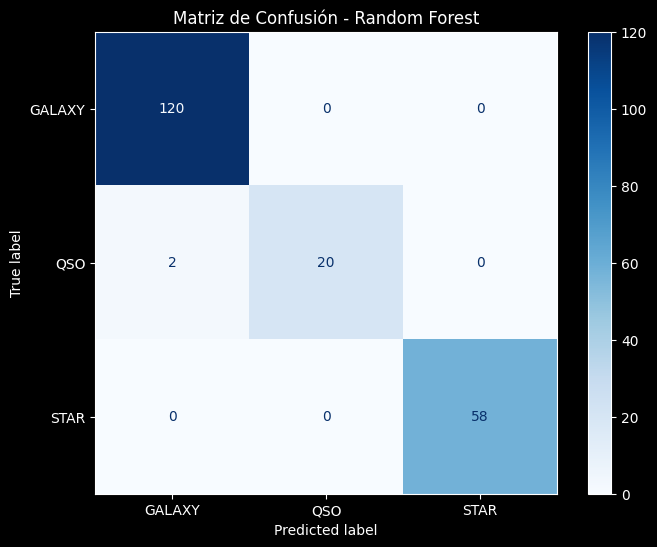

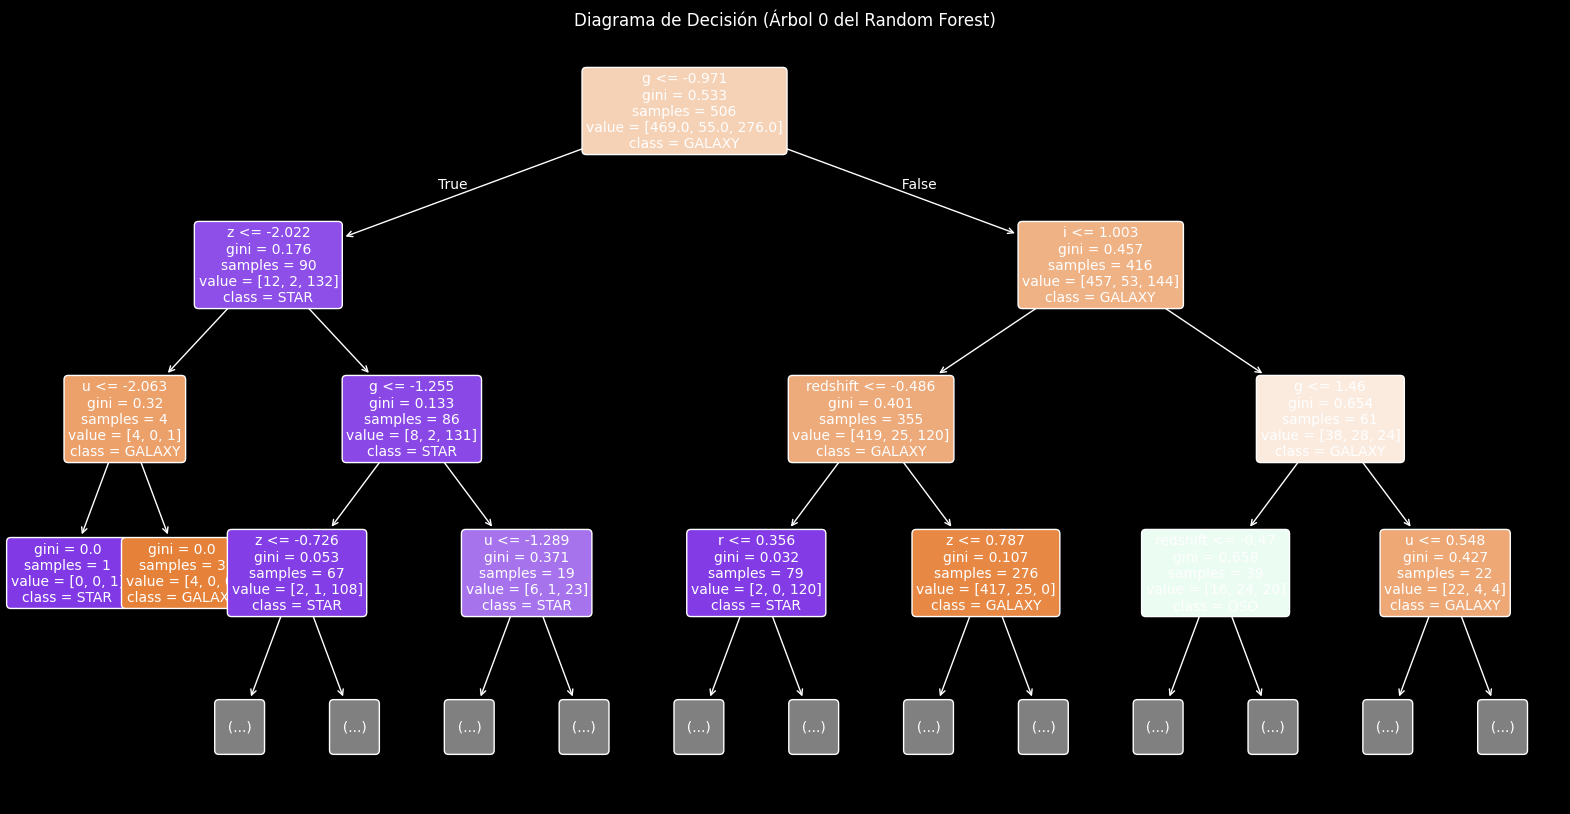

['cosmic_classifier.joblib']

In [1]:
#librerías
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import plot_tree
import pandas as pd
from joblib import dump

path = './data/Skyserver_data.csv'
#leer datos
df = pd.read_csv(path, skiprows=1, sep=None, engine='python')
print("Dataset cargado\n")
print(df.info())

#revisar datos
print("Revisar datos")
print(df.head(),end="\n")


#analisis exploratorio
print("Shape del dataset:", df.shape,end="\n")
print("\nColumnas:")
print(df.columns,end="\n")

#limpiar datos
X= df.drop(["objid","class"],axis=1)
Y= df["class"]

#variable objetivo de label a numeros
le = LabelEncoder()
Y= le.fit_transform(Y)

#train/test
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,train_size=0.8,test_size=0.2,random_state=42)

#normalizar valores (escalar)
scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

#entrenar modelo
model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train,Y_train)

#ver resultados
print(classification_report(Y_test,model.predict(X_test), target_names=le.classes_))

#visualizaciones
#confusion matrix
Y_pred = model.predict(X_test)
print("Matriz de Confusión")
cm = confusion_matrix(Y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Matriz de Confusión - Random Forest')
plt.show()

#tree
fig, ax = plt.subplots(figsize=(20, 10))

# model.estimators_[0] extrae el primer árbol de los 100 creados
plot_tree(model.estimators_[0],
          feature_names=X.columns,
          class_names=le.classes_,
          filled=True,
          rounded=True,
          max_depth=3, # Limitamos a 3 niveles para que sea legible en pantalla
          fontsize=10,
          ax=ax)

plt.title('Diagrama de Decisión (Árbol 0 del Random Forest)')
plt.show()



artifact = {
    "model": model,
    "scaler": scaler,
    "label_encoder": le,
    "columns": list(X.columns),
}

dump(artifact, "cosmic_classifier.joblib")